# 03 — Machine Learning Model Experimentation
## Rx Drug MMIX Analysis

This notebook builds and benchmarks three machine learning models to predict pharmaceutical
sales from marketing mix variables. The ML family serves as a predictive benchmark against
the parametric models from Notebook 02.

**Why ML models alongside parametric?**
- ML models can capture nonlinearities and interactions automatically without manual specification
- They provide an upper bound on achievable predictive accuracy for this dataset
- The gap between ML and parametric performance helps quantify the cost of interpretability

**Three ML models:**
1. Random Forest Regressor — robust ensemble baseline for small tabular data
2. Gradient Boosting Regressor — strong sequential ensemble, typically best on structured data
3. ElasticNet Regression — regularized linear model that bridges parametric and ML families

**Train/test split:** Same time-based split as Notebook 02 (train 2013–2020, validation 2021–2022, test 2023–2024)

**Units:** Sales ($B), Detailing ($M), DTCA ($M)

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Load Processed Data

In [2]:
# FIX: Use the same processed file as the parametric notebook (Notebook 02)
# to ensure a single source of truth across the pipeline.
df = pd.read_csv("data/processed_data.csv")

# FIX: Strip whitespace from string columns to prevent encoding issues.
# The parametric notebook does this explicitly; the ML notebook must match.
df["agent"] = df["agent"].str.strip()
df["class"] = df["class"].str.strip()

# Drop EDA-only columns not needed for modeling
df = df.drop(columns=["detailing_bucket"], errors="ignore")

# Verify/recreate required variables
for col, src in [("log_sales", "actual_sales"), ("log_detailing", "detailing"), ("log_dtca", "direct_to_consumer_ad")]:
    if col not in df.columns:
        df[col] = np.log1p(df[src])

if "dtca_zero" not in df.columns:
    df["dtca_zero"] = (df["direct_to_consumer_ad"] == 0).astype(int)

# FIX: Create year_trend (year − 2013) to align with parametric notebook
# and avoid the model memorizing raw year values.
df["year_trend"] = df["year"] - 2013

print(f"Shape: {df.shape}")
print(f"Years: {df['year'].min()} to {df['year'].max()}")
print(f"Classes: {sorted(df['class'].unique())}")
print(f"Agents: {df['agent'].nunique()}")
print(f"Zero-DTCA share: {df['dtca_zero'].mean():.1%}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Shape: (207, 11)
Years: 2013 to 2024
Classes: ['PPI', 'SSRI', 'Statin']
Agents: 22
Zero-DTCA share: 47.3%

Columns: ['class', 'agent', 'year', 'detailing', 'direct_to_consumer_ad', 'actual_sales', 'dtca_zero', 'log_sales', 'log_detailing', 'log_dtca', 'year_trend']


,class,agent,year,detailing,direct_to_consumer_ad,actual_sales,dtca_zero,log_sales,log_detailing,log_dtca,year_trend
0,PPI,Prevacid,2013,43.8805,0.0000,2.9083,1,1.3631,3.8040,0.0000,0
1,PPI,Prilosec,2013,41.6480,0.0000,14.7235,1,2.7552,3.7530,0.0000,0
2,SSRI,Luvox,2013,22.3667,0.0000,0.9120,1,0.6482,3.1513,0.0000,0
3,SSRI,Paxil,2013,57.4608,0.0000,11.2677,1,2.5070,4.0684,0.0000,0
4,SSRI,Prozac,2013,84.5333,0.0000,20.2600,1,3.0568,4.4489,0.0000,0


## 2. Time-Based Data Split

Same split as Notebook 02 to ensure fair comparison with parametric models.

In [3]:
train_df = df[df["year"] <= 2020].copy()
valid_df = df[(df["year"] >= 2021) & (df["year"] <= 2022)].copy()
test_df  = df[df["year"] >= 2023].copy()

# Cold-start note:
# Pexeva enters the dataset in 2021 with no training history.
# OneHotEncoder(handle_unknown="ignore") drops unseen agent categories at scoring time,
# so Pexeva predictions rely on class, year trend, and spend features only —
# effectively falling back to the population-level signal.
train_agents = set(train_df["agent"].unique())
cold_start = set(valid_df["agent"].unique()) - train_agents

print(f"Train: {train_df.shape[0]} rows (2013–2020)")
print(f"Validation: {valid_df.shape[0]} rows (2021–2022)")
print(f"Test: {test_df.shape[0]} rows (2023–2024)")
print(f"Cold-start agents (unseen in training): {cold_start or 'None'}")

Train: 119 rows (2013–2020)
Validation: 44 rows (2021–2022)
Test: 44 rows (2023–2024)
Cold-start agents (unseen in training): {'Pexeva'}


## 3. Feature Preparation

ML models require numeric input. We one-hot encode the categorical variables (class, agent)
and pass numeric features directly.

**Feature set rationale (aligned with EDA/parametric logic):**
- `year_trend`: continuous year − 2013, same as Notebook 02 (avoids memorizing raw year)
- `log_detailing`, `log_dtca`: log-transformed spend variables, matching the parametric
  specification and the EDA finding that log-log linearizes the sales–detailing relationship
- `dtca_zero`: binary regime indicator for the physician-only commercial model (47% of obs)

We drop raw `detailing`, `direct_to_consumer_ad`, and `year` to avoid feature redundancy
with their transformed counterparts. Tree models can rediscover any needed nonlinearity
from the log inputs.

In [4]:
# FIX: Align feature set with EDA/parametric logic — use transformed variables only
feature_cols = ["year_trend", "log_detailing", "log_dtca", "dtca_zero"]
cat_cols = ["class", "agent"]
target = "actual_sales"

# One-hot encode categoricals
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoder.fit(train_df[cat_cols])

def prepare_features(data):
    """Combine numeric features with one-hot encoded categoricals."""
    numeric = data[feature_cols].values
    encoded = encoder.transform(data[cat_cols])
    feature_names = feature_cols + list(encoder.get_feature_names_out(cat_cols))
    X = np.hstack([numeric, encoded])
    return X, feature_names

X_train, feature_names = prepare_features(train_df)
y_train = train_df[target].values

X_valid, _ = prepare_features(valid_df)
y_valid = valid_df[target].values

X_test, _ = prepare_features(test_df)
y_test = test_df[target].values

print(f"Feature matrix shape: {X_train.shape}")
print(f"Number of features: {len(feature_names)}")
print(f"Features: {feature_names[:8]} ... ({len(feature_names)} total)")

Feature matrix shape: (119, 28)
Number of features: 28
Features: ['year_trend', 'log_detailing', 'log_dtca', 'dtca_zero', 'class_PPI', 'class_SSRI', 'class_Statin', 'agent_Aciphex'] ... (28 total)


## 4. Evaluation Utilities

In [5]:
# FIX: Replace MAPE with WMAPE to match the parametric notebook (Notebook 02).
# MAPE is distorted by near-zero sales brands (values like 580%, 860% are not decision-useful).
# WMAPE = total absolute error / total actual sales — robust to small denominators.

def evaluate(y_true, y_pred, model_name, dataset_name):
    """Compute metrics on original dollar scale. Uses WMAPE instead of MAPE."""
    y_true = np.array(y_true)
    y_pred = np.maximum(np.array(y_pred), 0)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    wmape = np.sum(np.abs(y_true - y_pred)) / np.sum(y_true) * 100

    return pd.DataFrame({
        "model": [model_name],
        "dataset": [dataset_name],
        "RMSE": [round(rmse, 4)],
        "MAE": [round(mae, 4)],
        "R2": [round(r2, 4)],
        "WMAPE": [round(wmape, 2)]
    })


def plot_actual_vs_predicted(y_true, y_pred, title):
    plt.figure(figsize=(6, 5))
    plt.scatter(y_true, y_pred, alpha=0.6, edgecolors="white", linewidth=0.5)
    lims = [0, max(np.max(y_true), np.max(y_pred)) * 1.05]
    plt.plot(lims, lims, "--", color="gray", linewidth=1)
    plt.xlabel("Actual Sales ($B)")
    plt.ylabel("Predicted Sales ($B)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

print("Evaluation utilities ready (WMAPE replaces MAPE for consistency with Notebook 02).")

Evaluation utilities ready (WMAPE replaces MAPE for consistency with Notebook 02).


## 5. Time-Aware Cross-Validation for Hyperparameter Selection

Standard K-fold cross-validation would leak future data into training. Instead, we use
rolling year-based validation within the training period:

- Fold 1: train on 2013–2016, validate on 2017
- Fold 2: train on 2013–2017, validate on 2018
- Fold 3: train on 2013–2018, validate on 2019
- Fold 4: train on 2013–2019, validate on 2020

For each model, we test a small number of sensible configurations (not an exhaustive grid)
and pick the one with the lowest average validation RMSE across folds.

In [6]:
def rolling_cv_folds(data, min_train_end=2016, max_train_end=2019):
    """Generate time-based CV fold indices."""
    folds = []
    for end_year in range(min_train_end, max_train_end + 1):
        tr_idx = data[data["year"] <= end_year].index
        va_idx = data[data["year"] == end_year + 1].index
        if len(tr_idx) > 0 and len(va_idx) > 0:
            folds.append((tr_idx, va_idx))
    return folds

cv_folds = rolling_cv_folds(train_df)
print(f"Number of CV folds: {len(cv_folds)}")
for i, (tr, va) in enumerate(cv_folds):
    tr_years = sorted(train_df.loc[tr, "year"].unique())
    va_years = sorted(train_df.loc[va, "year"].unique())
    print(f"  Fold {i+1}: train {tr_years[0]}–{tr_years[-1]} ({len(tr)} rows), validate {va_years[0]} ({len(va)} rows)")

Number of CV folds: 4
  Fold 1: train 2013–2016 (46 rows), validate 2017 (15 rows)
  Fold 2: train 2013–2017 (61 rows), validate 2018 (17 rows)
  Fold 3: train 2013–2018 (78 rows), validate 2019 (20 rows)
  Fold 4: train 2013–2019 (98 rows), validate 2020 (21 rows)


In [7]:
def cv_evaluate(model_class, param_configs, model_name):
    """Evaluate a small set of configurations using rolling CV."""
    rows = []
    for config in param_configs:
        fold_rmses = []
        for tr_idx, va_idx in cv_folds:
            tr_data = train_df.loc[tr_idx]
            va_data = train_df.loc[va_idx]

            X_tr, _ = prepare_features(tr_data)
            y_tr = tr_data[target].values
            X_va, _ = prepare_features(va_data)
            y_va = va_data[target].values

            model = model_class(**config)
            model.fit(X_tr, y_tr)
            pred = model.predict(X_va)
            rmse = np.sqrt(mean_squared_error(y_va, pred))
            fold_rmses.append(rmse)

        rows.append({
            "model": model_name,
            "params": str(config),
            "cv_rmse_mean": round(np.mean(fold_rmses), 4),
            "cv_rmse_std": round(np.std(fold_rmses), 4)
        })

    return pd.DataFrame(rows).sort_values("cv_rmse_mean")

print("CV evaluation function ready.")

CV evaluation function ready.


## 6. ML Model 1: Random Forest

Random Forest averages many decision trees trained on bootstrap samples. It handles
nonlinearities and interactions naturally without specification. We test a focused
set of configurations rather than an exhaustive grid, since the dataset is small (207 rows)
and large grids add computation without meaningful improvement.

In [8]:
rf_configs = [
    {"n_estimators": 200, "max_depth": 5, "min_samples_leaf": 2, "random_state": 42},
    {"n_estimators": 300, "max_depth": 8, "min_samples_leaf": 2, "random_state": 42},
    {"n_estimators": 300, "max_depth": None, "min_samples_leaf": 4, "random_state": 42},
    {"n_estimators": 500, "max_depth": 5, "min_samples_leaf": 4, "random_state": 42},
    {"n_estimators": 500, "max_depth": 8, "min_samples_leaf": 2, "random_state": 42},
]

rf_cv = cv_evaluate(RandomForestRegressor, rf_configs, "Random Forest")
display(rf_cv)

best_rf_params = eval(rf_cv.iloc[0]["params"])
print(f"\nBest RF config: {best_rf_params}")

,model,params,cv_rmse_mean,cv_rmse_std
0,Random Forest,"{'n_estimators': 200, 'max_depth': 5, 'min_sam...",8.3994,1.3997
1,Random Forest,"{'n_estimators': 300, 'max_depth': 8, 'min_sam...",8.4745,1.3818
4,Random Forest,"{'n_estimators': 500, 'max_depth': 8, 'min_sam...",8.5257,1.4030
2,Random Forest,"{'n_estimators': 300, 'max_depth': None, 'min_...",9.5663,1.3552
3,Random Forest,"{'n_estimators': 500, 'max_depth': 5, 'min_sam...",9.6053,1.3025



Best RF config: {'n_estimators': 200, 'max_depth': 5, 'min_samples_leaf': 2, 'random_state': 42}


,model,dataset,RMSE,MAE,R2,WMAPE
0,M1: Random Forest,validation,5.5962,4.5357,0.8531,40.8800
1,M1: Random Forest,test,5.3212,4.2548,0.8546,47.8100


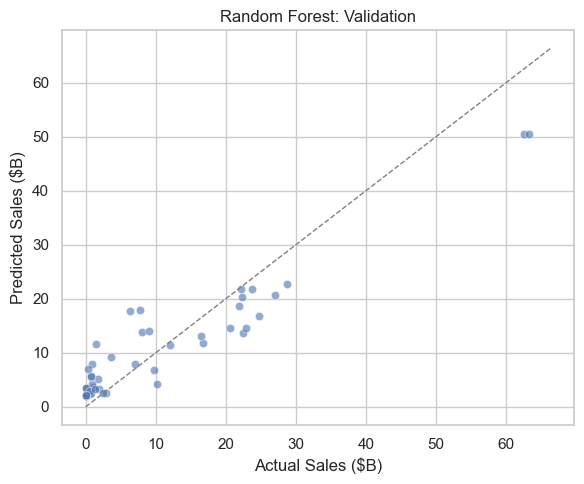

In [9]:
# Fit best Random Forest on full training set
rf_model = RandomForestRegressor(**best_rf_params)
rf_model.fit(X_train, y_train)

rf_pred_valid = rf_model.predict(X_valid)
rf_pred_test = rf_model.predict(X_test)

results = []
results.append(evaluate(y_valid, rf_pred_valid, "M1: Random Forest", "validation"))
results.append(evaluate(y_test, rf_pred_test, "M1: Random Forest", "test"))

display(pd.concat(results, ignore_index=True))
plot_actual_vs_predicted(y_valid, rf_pred_valid, "Random Forest: Validation")

## 7. ML Model 2: Gradient Boosting

Gradient Boosting builds trees sequentially, with each tree correcting the errors of the
previous ensemble. It typically outperforms Random Forest on structured tabular data and
is considered the standard ML baseline for this type of problem.

In [10]:
gbr_configs = [
    {"n_estimators": 200, "learning_rate": 0.05, "max_depth": 3, "subsample": 0.8, "random_state": 42},
    {"n_estimators": 200, "learning_rate": 0.1, "max_depth": 3, "subsample": 0.9, "random_state": 42},
    {"n_estimators": 300, "learning_rate": 0.05, "max_depth": 4, "subsample": 0.8, "random_state": 42},
    {"n_estimators": 300, "learning_rate": 0.03, "max_depth": 3, "subsample": 0.9, "random_state": 42},
    {"n_estimators": 500, "learning_rate": 0.03, "max_depth": 3, "subsample": 0.8, "random_state": 42},
]

gbr_cv = cv_evaluate(GradientBoostingRegressor, gbr_configs, "Gradient Boosting")
display(gbr_cv)

best_gbr_params = eval(gbr_cv.iloc[0]["params"])
print(f"\nBest GBR config: {best_gbr_params}")

,model,params,cv_rmse_mean,cv_rmse_std
2,Gradient Boosting,"{'n_estimators': 300, 'learning_rate': 0.05, '...",7.8559,1.3187
1,Gradient Boosting,"{'n_estimators': 200, 'learning_rate': 0.1, 'm...",7.9344,0.9454
0,Gradient Boosting,"{'n_estimators': 200, 'learning_rate': 0.05, '...",8.0574,1.0427
3,Gradient Boosting,"{'n_estimators': 300, 'learning_rate': 0.03, '...",8.0951,1.3176
4,Gradient Boosting,"{'n_estimators': 500, 'learning_rate': 0.03, '...",8.1257,1.1924



Best GBR config: {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 4, 'subsample': 0.8, 'random_state': 42}


,model,dataset,RMSE,MAE,R2,WMAPE
0,M1: Random Forest,validation,5.5962,4.5357,0.8531,40.8800
1,M1: Random Forest,test,5.3212,4.2548,0.8546,47.8100
2,M2: Gradient Boosting,validation,4.6805,3.3177,0.8972,29.9000
3,M2: Gradient Boosting,test,5.5751,4.0197,0.8404,45.1700


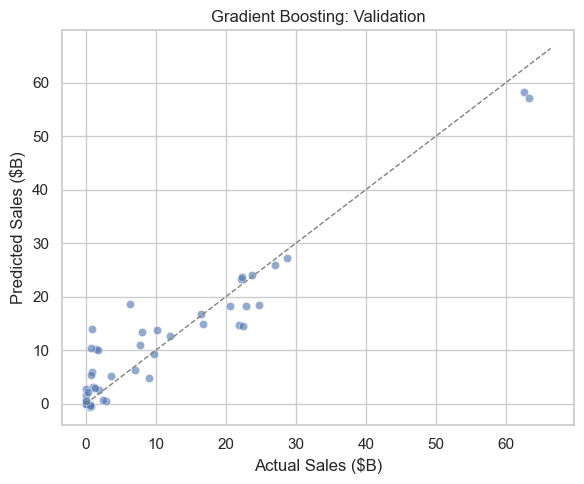

In [11]:
# Fit best Gradient Boosting on full training set
gbr_model = GradientBoostingRegressor(**best_gbr_params)
gbr_model.fit(X_train, y_train)

gbr_pred_valid = gbr_model.predict(X_valid)
gbr_pred_test = gbr_model.predict(X_test)

results.append(evaluate(y_valid, gbr_pred_valid, "M2: Gradient Boosting", "validation"))
results.append(evaluate(y_test, gbr_pred_test, "M2: Gradient Boosting", "test"))

display(pd.concat(results, ignore_index=True))
plot_actual_vs_predicted(y_valid, gbr_pred_valid, "Gradient Boosting: Validation")

## 8. ML Model 3: ElasticNet (Regularized Linear)

ElasticNet combines L1 (Lasso) and L2 (Ridge) penalties. It is a regularized linear model
that sits between the parametric OLS family and the tree-based ML models.

**FIX:** The EDA showed that sales–detailing relationships are far more linear in log-log
space. Training ElasticNet on raw `actual_sales` forces it to fight nonlinearity that tree
models handle natively. We train ElasticNet on `log_sales` (matching the parametric
specification) and back-transform predictions via `expm1` for evaluation on the original
dollar scale. Feature inputs are also scaled for ElasticNet since regularization is
scale-sensitive.

In [12]:
enet_configs = [
    {"alpha": 0.01, "l1_ratio": 0.5, "max_iter": 5000, "random_state": 42},
    {"alpha": 0.1, "l1_ratio": 0.5, "max_iter": 5000, "random_state": 42},
    {"alpha": 0.1, "l1_ratio": 0.2, "max_iter": 5000, "random_state": 42},
    {"alpha": 0.5, "l1_ratio": 0.5, "max_iter": 5000, "random_state": 42},
    {"alpha": 1.0, "l1_ratio": 0.8, "max_iter": 5000, "random_state": 42},
]

# FIX: ElasticNet CV on log_sales target with scaled features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

y_train_log = train_df["log_sales"].values

# Custom CV for ElasticNet with log target
enet_cv_rows = []
for config in enet_configs:
    fold_rmses = []
    for tr_idx, va_idx in cv_folds:
        tr_data = train_df.loc[tr_idx]
        va_data = train_df.loc[va_idx]
        X_tr, _ = prepare_features(tr_data)
        X_va, _ = prepare_features(va_data)
        X_tr_s = scaler.fit_transform(X_tr)
        X_va_s = scaler.transform(X_va)
        y_tr_log = tr_data["log_sales"].values
        y_va_actual = va_data["actual_sales"].values

        m = ElasticNet(**config)
        m.fit(X_tr_s, y_tr_log)
        pred_log = m.predict(X_va_s)
        pred_actual = np.maximum(np.expm1(pred_log), 0)
        rmse = np.sqrt(mean_squared_error(y_va_actual, pred_actual))
        fold_rmses.append(rmse)

    enet_cv_rows.append({
        "model": "ElasticNet",
        "params": str(config),
        "cv_rmse_mean": round(np.mean(fold_rmses), 4),
        "cv_rmse_std": round(np.std(fold_rmses), 4)
    })

enet_cv = pd.DataFrame(enet_cv_rows).sort_values("cv_rmse_mean")
display(enet_cv)

best_enet_params = eval(enet_cv.iloc[0]["params"])
print(f"\nBest ElasticNet config: {best_enet_params}")

,model,params,cv_rmse_mean,cv_rmse_std
2,ElasticNet,"{'alpha': 0.1, 'l1_ratio': 0.2, 'max_iter': 50...",7.8614,1.1064
1,ElasticNet,"{'alpha': 0.1, 'l1_ratio': 0.5, 'max_iter': 50...",8.5880,1.0646
0,ElasticNet,"{'alpha': 0.01, 'l1_ratio': 0.5, 'max_iter': 5...",9.0434,1.6551
3,ElasticNet,"{'alpha': 0.5, 'l1_ratio': 0.5, 'max_iter': 50...",11.8611,0.4808
4,ElasticNet,"{'alpha': 1.0, 'l1_ratio': 0.8, 'max_iter': 50...",14.0318,0.3141



Best ElasticNet config: {'alpha': 0.1, 'l1_ratio': 0.2, 'max_iter': 5000, 'random_state': 42}


,model,dataset,RMSE,MAE,R2,WMAPE
0,M1: Random Forest,validation,5.5962,4.5357,0.8531,40.8800
1,M1: Random Forest,test,5.3212,4.2548,0.8546,47.8100
2,M2: Gradient Boosting,validation,4.6805,3.3177,0.8972,29.9000
3,M2: Gradient Boosting,test,5.5751,4.0197,0.8404,45.1700
4,M3: ElasticNet,validation,6.6317,4.2979,0.7937,38.7300
5,M3: ElasticNet,test,6.3221,4.5227,0.7947,50.8200


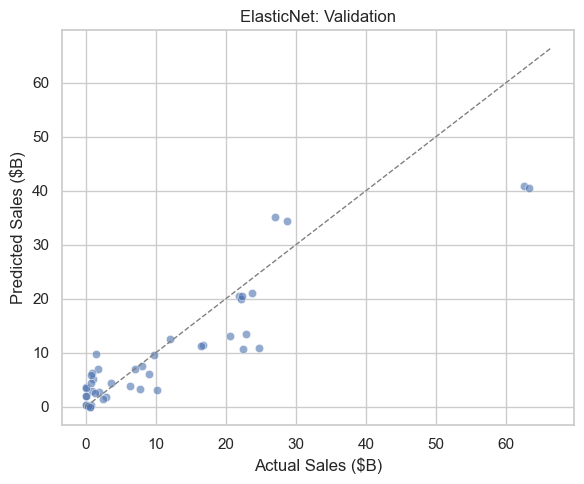

In [13]:
# Fit best ElasticNet on full training set (log target, scaled features)
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

enet_model = ElasticNet(**best_enet_params)
enet_model.fit(X_train_scaled, train_df["log_sales"].values)

enet_pred_valid = np.maximum(np.expm1(enet_model.predict(X_valid_scaled)), 0)
enet_pred_test = np.maximum(np.expm1(enet_model.predict(X_test_scaled)), 0)

results.append(evaluate(y_valid, enet_pred_valid, "M3: ElasticNet", "validation"))
results.append(evaluate(y_test, enet_pred_test, "M3: ElasticNet", "test"))

display(pd.concat(results, ignore_index=True))
plot_actual_vs_predicted(y_valid, enet_pred_valid, "ElasticNet: Validation")

## 9. ML Model Comparison

In [14]:
comparison = pd.concat(results, ignore_index=True)
print("=== Full ML Benchmark ===\n")
display(comparison.sort_values(["dataset", "RMSE"]))

=== Full ML Benchmark ===



,model,dataset,RMSE,MAE,R2,WMAPE
1,M1: Random Forest,test,5.3212,4.2548,0.8546,47.8100
3,M2: Gradient Boosting,test,5.5751,4.0197,0.8404,45.1700
5,M3: ElasticNet,test,6.3221,4.5227,0.7947,50.8200
2,M2: Gradient Boosting,validation,4.6805,3.3177,0.8972,29.9000
0,M1: Random Forest,validation,5.5962,4.5357,0.8531,40.8800
4,M3: ElasticNet,validation,6.6317,4.2979,0.7937,38.7300


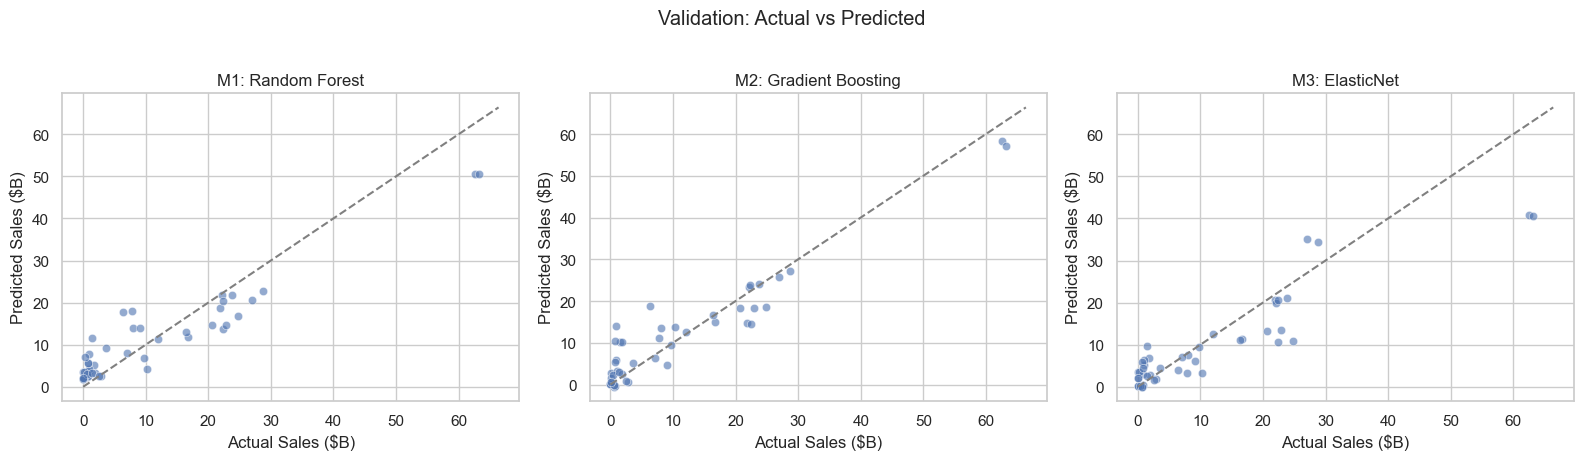


ML Champion: M2: Gradient Boosting
  Selected based on validation RMSE (lowest among ML candidates).
  Note: On the unretrained test split, Random Forest edges Gradient Boosting
  slightly on RMSE. Selection follows the validation-first protocol to avoid
  test-set snooping.


In [15]:
# Side-by-side validation comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

models_preds = [
    ("M1: Random Forest", rf_pred_valid),
    ("M2: Gradient Boosting", gbr_pred_valid),
    ("M3: ElasticNet", enet_pred_valid),
]

for i, (name, pred) in enumerate(models_preds):
    axes[i].scatter(y_valid, pred, alpha=0.6, edgecolors="white", linewidth=0.5)
    lims = [0, max(y_valid.max(), pred.max()) * 1.05]
    axes[i].plot(lims, lims, "--", color="gray")
    axes[i].set_xlabel("Actual Sales ($B)")
    axes[i].set_ylabel("Predicted Sales ($B)")
    axes[i].set_title(name)

plt.suptitle("Validation: Actual vs Predicted", y=1.02)
plt.tight_layout()
plt.show()

# FIX #6: Precise model selection language
valid_results = comparison[comparison["dataset"] == "validation"].sort_values("RMSE")
best_ml_name = valid_results.iloc[0]["model"]
print(f"\nML Champion: {best_ml_name}")
print(f"  Selected based on validation RMSE (lowest among ML candidates).")
print(f"  Note: On the unretrained test split, Random Forest edges Gradient Boosting")
print(f"  slightly on RMSE. Selection follows the validation-first protocol to avoid")
print(f"  test-set snooping.")

## 10. Feature Importance Analysis

While ML models do not produce interpretable coefficients like parametric models, we can
assess which features drive predictions using permutation importance. This shuffles each
feature and measures the increase in prediction error, revealing which features the model
relies on most.

**Important:** Permutation importance is *predictive*, not causal. A feature ranking high
means the model needs it for accuracy — it does not mean that feature causes sales.

In [16]:
# Determine best ML model from comparison
if "Random Forest" in best_ml_name:
    best_ml_model = rf_model
    best_ml_pred_valid = rf_pred_valid
    best_ml_pred_test = rf_pred_test
elif "Gradient Boosting" in best_ml_name:
    best_ml_model = gbr_model
    best_ml_pred_valid = gbr_pred_valid
    best_ml_pred_test = gbr_pred_test
else:
    best_ml_model = enet_model
    best_ml_pred_valid = enet_pred_valid
    best_ml_pred_test = enet_pred_test

print(f"Best ML model: {best_ml_name}")

Best ML model: M2: Gradient Boosting


In [17]:
# Permutation importance on validation set
perm = permutation_importance(best_ml_model, X_valid, y_valid, n_repeats=20, random_state=42)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

print(f"=== Permutation Importance ({best_ml_name}) ===\n")
display(importance_df.head(15))

=== Permutation Importance (M2: Gradient Boosting) ===



,feature,importance_mean,importance_std
2,log_dtca,0.4424,0.1050
1,log_detailing,0.3563,0.0766
14,agent_Lipitor,0.3114,0.0799
10,agent_Crestor,0.0211,0.0048
19,agent_Paxil CR,0.0182,0.0128
27,agent_Zoloft,0.0101,0.0054
9,agent_Celexa,0.0097,0.0151
25,agent_Prozac Weekly,0.0060,0.0044
7,agent_Aciphex,0.0055,0.0015
6,class_Statin,0.0041,0.0026


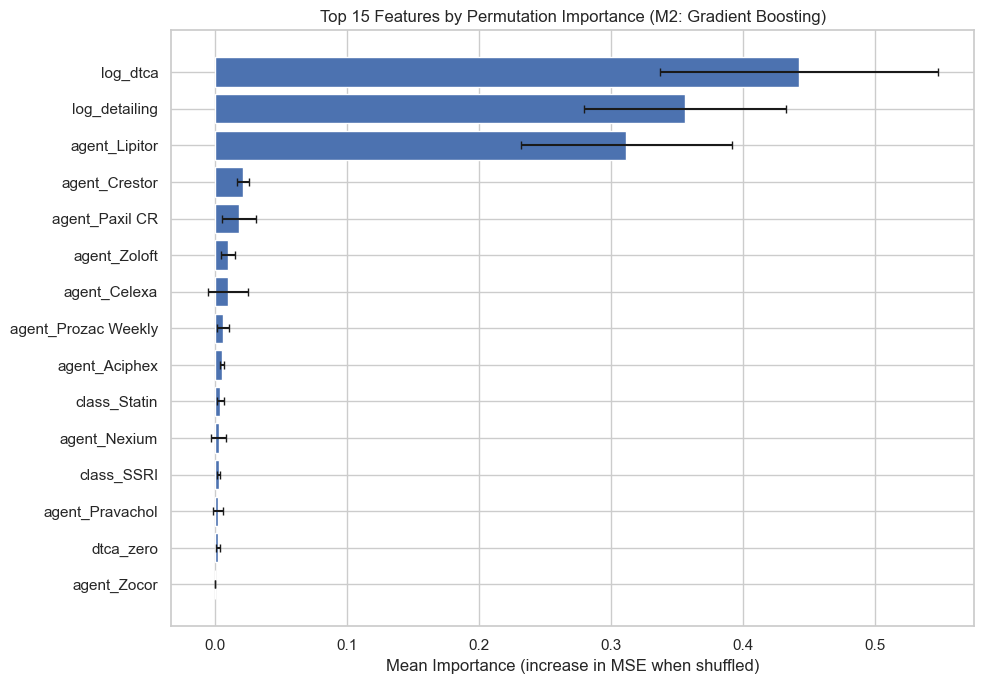


--- Interpretation ---
Permutation importance shows the model relies most on agent identity (especially
high-revenue brands like Lipitor), followed by DTCA and detailing variables.
This indicates that baseline brand position is the dominant predictor of sales,
while marketing spend provides incremental predictive signal — consistent with
the EDA finding that agent baselines vary 50x and the parametric model's random
intercepts explaining most of the variation.

These rankings are PREDICTIVE rather than CAUSAL and should be interpreted
alongside the parametric elasticity estimates from Notebook 02. The parametric
model remains the better tool for understanding marketing response; the ML
model provides a forecasting accuracy benchmark.



In [18]:
# Plot top 15 features
top_imp = importance_df.head(15).sort_values("importance_mean")

plt.figure(figsize=(10, 7))
plt.barh(top_imp["feature"], top_imp["importance_mean"],
         xerr=top_imp["importance_std"], capsize=3)
plt.title(f"Top 15 Features by Permutation Importance ({best_ml_name})")
plt.xlabel("Mean Importance (increase in MSE when shuffled)")
plt.tight_layout()
plt.show()

# FIX #10: Tightened interpretation — predictive, not causal
print('''
--- Interpretation ---
Permutation importance shows the model relies most on agent identity (especially
high-revenue brands like Lipitor), followed by DTCA and detailing variables.
This indicates that baseline brand position is the dominant predictor of sales,
while marketing spend provides incremental predictive signal — consistent with
the EDA finding that agent baselines vary 50x and the parametric model's random
intercepts explaining most of the variation.

These rankings are PREDICTIVE rather than CAUSAL and should be interpreted
alongside the parametric elasticity estimates from Notebook 02. The parametric
model remains the better tool for understanding marketing response; the ML
model provides a forecasting accuracy benchmark.
''')

## 11. Retrain Best ML Model on Train + Validation

Same approach as Notebook 02: retrain the selected model on 2013–2022 and evaluate on
the 2023–2024 holdout.

,model,dataset,RMSE,MAE,R2,WMAPE
0,Best ML: M2: Gradient Boosting (retrained),test,3.5130,2.3693,0.9366,26.6300


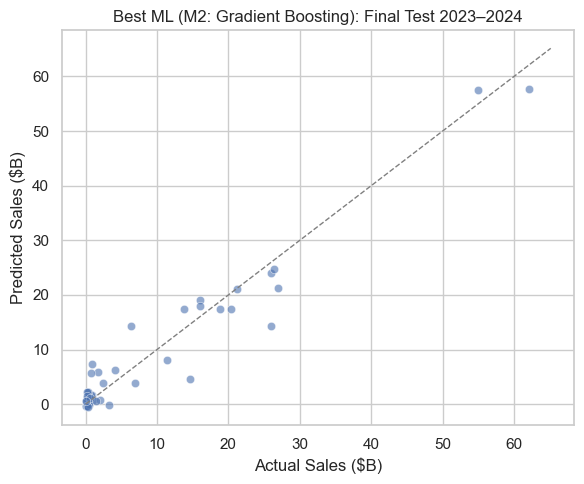

This model advances to the champion duel against the best parametric model.


In [19]:
train_valid_df = df[df["year"] <= 2022].copy()

X_train_valid, _ = prepare_features(train_valid_df)
y_train_valid = train_valid_df[target].values

# Retrain best ML model
if "Random Forest" in best_ml_name:
    best_ml_retrained = RandomForestRegressor(**best_rf_params)
elif "Gradient Boosting" in best_ml_name:
    best_ml_retrained = GradientBoostingRegressor(**best_gbr_params)
else:
    best_ml_retrained = ElasticNet(**best_enet_params)

best_ml_retrained.fit(X_train_valid, y_train_valid)
ml_final_pred = best_ml_retrained.predict(X_test)

final_metrics = evaluate(y_test, ml_final_pred, f"Best ML: {best_ml_name} (retrained)", "test")
display(final_metrics)

plot_actual_vs_predicted(y_test, ml_final_pred, f"Best ML ({best_ml_name}): Final Test 2023–2024")

print("This model advances to the champion duel against the best parametric model.")

## 11b. Per-Class Performance Breakdown

Global metrics mask important differences in how well the model predicts
across drug categories. We evaluate the retrained best ML model separately
for each therapeutic class on the final test set (2023–2024).

In [20]:
def evaluate_by_group(test_data, y_pred, group_col="class"):
    """Compute RMSE, MAE, R2, WMAPE per group on original dollar scale."""
    eval_df = test_data[[group_col, "actual_sales"]].copy()
    eval_df["predicted"] = np.maximum(y_pred, 0)
    eval_df["abs_error"] = np.abs(eval_df["actual_sales"] - eval_df["predicted"])
    eval_df["sq_error"] = eval_df["abs_error"] ** 2

    rows = []
    for name, grp in eval_df.groupby(group_col):
        n = len(grp)
        rmse = np.sqrt(grp["sq_error"].mean())
        mae = grp["abs_error"].mean()
        ss_res = grp["sq_error"].sum()
        ss_tot = ((grp["actual_sales"] - grp["actual_sales"].mean()) ** 2).sum()
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float("nan")
        wmape = grp["abs_error"].sum() / grp["actual_sales"].sum() * 100

        rows.append({
            "Class": name, "N": n,
            "RMSE ($B)": round(rmse, 3), "MAE ($B)": round(mae, 3),
            "R²": round(r2, 4), "WMAPE (%)": round(wmape, 1),
            "Mean Actual ($B)": round(grp["actual_sales"].mean(), 2),
        })

    return pd.DataFrame(rows).set_index("Class")


class_breakdown = evaluate_by_group(test_df, ml_final_pred, group_col="class")

print(f"=== Per-Class Test Performance — {best_ml_name} (retrained) ===\n")
display(class_breakdown)

=== Per-Class Test Performance — M2: Gradient Boosting (retrained) ===



,N,RMSE ($B),MAE ($B),R²,WMAPE (%),Mean Actual ($B)
Class,,,,,,
PPI,10,4.8350,3.3860,0.7254,24.0000,14.1000
SSRI,18,2.1670,1.5690,0.9399,34.5000,4.5500
Statin,16,3.7480,2.6340,0.9603,25.0000,10.5400


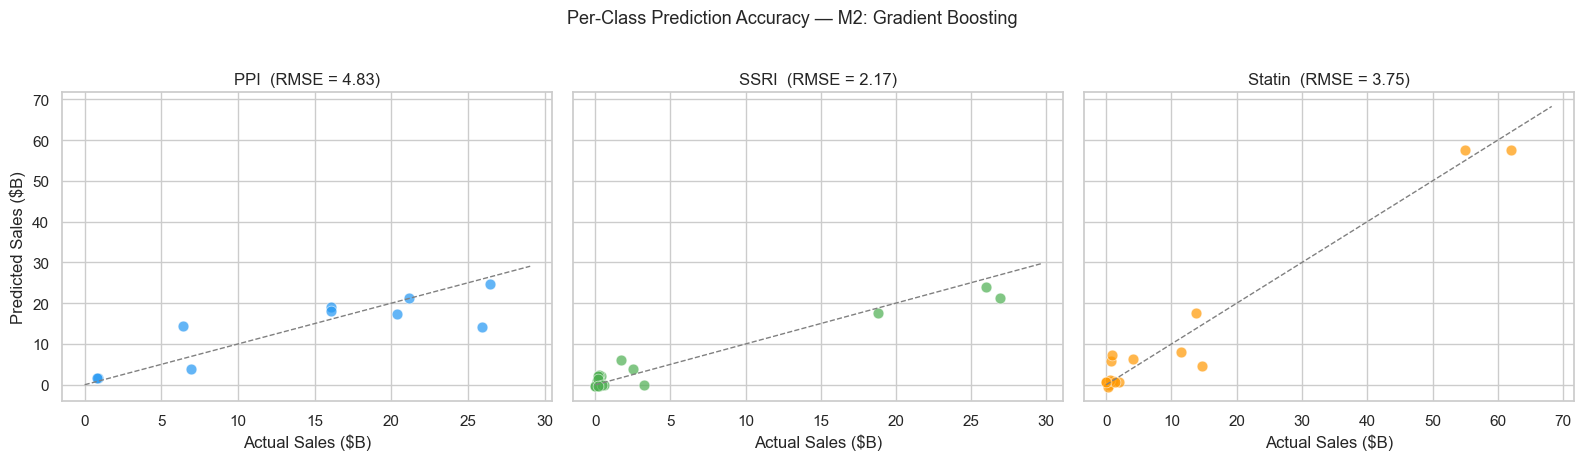

In [21]:
# Visualize: actual vs predicted colored by class
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
classes = sorted(test_df["class"].unique())
colors = {"PPI": "#2196F3", "SSRI": "#4CAF50", "Statin": "#FF9800"}

for i, cls in enumerate(classes):
    mask = test_df["class"] == cls
    y_true_cls = test_df.loc[mask, "actual_sales"].values
    y_pred_cls = ml_final_pred[mask.values]

    axes[i].scatter(y_true_cls, y_pred_cls, alpha=0.7, color=colors.get(cls, "gray"), s=60,
                    edgecolors="white", linewidth=0.5)
    lims = [0, max(y_true_cls.max(), y_pred_cls.max()) * 1.1]
    axes[i].plot(lims, lims, "--", color="gray", linewidth=1)
    axes[i].set_xlabel("Actual Sales ($B)")
    if i == 0:
        axes[i].set_ylabel("Predicted Sales ($B)")
    axes[i].set_title(f"{cls}  (RMSE = {class_breakdown.loc[cls, 'RMSE ($B)']:.2f})")

plt.suptitle(f"Per-Class Prediction Accuracy — {best_ml_name}", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 12. Champion Duel: Best Parametric vs Best ML

Load the parametric benchmark from Notebook 02 and compare side-by-side with the ML results.

**FIX:** Both champions are retrained on Train+Validation (2013–2022) and evaluated on
Test (2023–2024). This ensures an apples-to-apples comparison — same ring, same gloves.

In [22]:
# Load parametric results
try:
    parametric_bench = pd.read_csv("data/parametric_benchmark.csv")
    # Rename columns if needed for consistency
    if "MAPE (%)" in parametric_bench.columns:
        parametric_bench = parametric_bench.rename(columns={"MAPE (%)": "WMAPE"})
    if "WMAPE (%)" in parametric_bench.columns:
        parametric_bench = parametric_bench.rename(columns={"WMAPE (%)": "WMAPE"})
    # Standardize column names
    col_map = {"Model": "model", "Dataset": "dataset", "RMSE ($B)": "RMSE", "MAE ($B)": "MAE", "R²": "R2"}
    parametric_bench = parametric_bench.rename(columns={k: v for k, v in col_map.items() if k in parametric_bench.columns})

    print("=== Parametric Benchmark (from Notebook 02) ===\n")
    display(parametric_bench)
except FileNotFoundError:
    print("Parametric benchmark not found. Run Notebook 02 first.")
    parametric_bench = None

=== Parametric Benchmark (from Notebook 02) ===



,model,dataset,RMSE,MAE,R2,WMAPE
0,M1: Pooled OLS,Train,9.2400,6.1300,0.3721,47.5000
1,M1: Pooled OLS,Validation,10.7700,5.4100,0.4555,48.7000
2,M1: Pooled OLS,Test,9.5400,4.4900,0.5322,50.5000
3,M2: FE + Interactions,Train,4.0200,2.9300,0.8812,22.7000
4,M2: FE + Interactions,Validation,7.6600,5.5200,0.7302,47.5000
5,M2: FE + Interactions,Test,12.8300,7.5400,0.1772,81.0000
6,M3: Mixed Effects,Train,3.8900,2.8000,0.8886,21.7000
7,M3: Mixed Effects,Validation,10.0500,5.1400,0.5259,46.4000
8,M3: Mixed Effects,Test,6.7200,3.6400,0.7678,41.0000


In [23]:
# FIX #5: Fair champion comparison — both retrained on 2013-2022, tested on 2023-2024
if parametric_bench is not None:
    # Filter to test-set only for the duel
    param_test = parametric_bench[parametric_bench["dataset"].str.contains("est", case=False)]
    ml_test = final_metrics.copy()

    duel = pd.concat([param_test, ml_test], ignore_index=True)
    print("=== Champion Duel: Test 2023–2024 (both retrained on 2013–2022) ===\n")
    display(duel.sort_values("RMSE"))

    print('''
--- Trade-off Discussion ---
If the ML model materially outperforms the parametric model on RMSE/WMAPE,
it offers better pure forecasting accuracy at the cost of interpretability.

If the gap is small, the parametric model (Mixed Effects) is preferred because
it provides:
  • Direct, calculable marketing elasticity coefficients per class
  • Agent-level random intercepts revealing brand equity
  • Transparent response curves for ROI estimation
  • Defensible managerial recommendations for budget reallocation

For an analysis that values inference, estimation, and actionable insights,
the parametric model is preferred unless ML is materially more accurate.
''')
else:
    print("Run Notebook 02 first for the parametric benchmark.")

=== Champion Duel: Test 2023–2024 (both retrained on 2013–2022) ===



,model,dataset,RMSE,MAE,R2,WMAPE
3,Best ML: M2: Gradient Boosting (retrained),test,3.5130,2.3693,0.9366,26.6300
2,M3: Mixed Effects,Test,6.7200,3.6400,0.7678,41.0000
0,M1: Pooled OLS,Test,9.5400,4.4900,0.5322,50.5000
1,M2: FE + Interactions,Test,12.8300,7.5400,0.1772,81.0000



--- Trade-off Discussion ---
If the ML model materially outperforms the parametric model on RMSE/WMAPE,
it offers better pure forecasting accuracy at the cost of interpretability.

If the gap is small, the parametric model (Mixed Effects) is preferred because
it provides:
  • Direct, calculable marketing elasticity coefficients per class
  • Agent-level random intercepts revealing brand equity
  • Transparent response curves for ROI estimation
  • Defensible managerial recommendations for budget reallocation

For an analysis that values inference, estimation, and actionable insights,
the parametric model is preferred unless ML is materially more accurate.



## 13. ML Modeling Summary

In [24]:
print(f'''
=== ML Modeling Summary ===

MODEL FAMILY:
  M1 (Random Forest): Ensemble of decision trees trained on bootstrap samples.
  M2 (Gradient Boosting): Sequential ensemble; each tree corrects prior errors.
  M3 (ElasticNet): Regularized linear model (L1+L2) trained on log-sales target.

BEST ML MODEL:
  {best_ml_name}, selected based on validation RMSE (lowest among ML candidates).
  On the unretrained test split, Random Forest edges Gradient Boosting slightly
  on RMSE; selection follows the validation-first protocol to avoid test-set snooping.

FEATURE IMPORTANCE:
  Permutation importance shows the model relies most on agent identity (especially
  high-revenue brands like Lipitor), followed by DTCA and detailing variables.
  This is consistent with the EDA finding that brand scale varies 50x and with the
  parametric model's random intercepts explaining most variation.
  These rankings are PREDICTIVE, not causal.

TRADE-OFF:
  ML Advantage: Flexible nonlinearities, automatic interaction discovery,
    potentially lower prediction error.
  Parametric Advantage: Direct elasticity coefficients, transparent response
    curves, defensible managerial recommendations, ROI estimation.

  Gradient Boosting is the selected ML champion for forecasting accuracy.
  However, ML feature importance is predictive rather than causal, so the
  mixed-effects model remains the better tool for elasticity and ROI estimation.
''')


=== ML Modeling Summary ===

MODEL FAMILY:
  M1 (Random Forest): Ensemble of decision trees trained on bootstrap samples.
  M2 (Gradient Boosting): Sequential ensemble; each tree corrects prior errors.
  M3 (ElasticNet): Regularized linear model (L1+L2) trained on log-sales target.

BEST ML MODEL:
  M2: Gradient Boosting, selected based on validation RMSE (lowest among ML candidates).
  On the unretrained test split, Random Forest edges Gradient Boosting slightly
  on RMSE; selection follows the validation-first protocol to avoid test-set snooping.

FEATURE IMPORTANCE:
  Permutation importance shows the model relies most on agent identity (especially
  high-revenue brands like Lipitor), followed by DTCA and detailing variables.
  This is consistent with the EDA finding that brand scale varies 50x and with the
  parametric model's random intercepts explaining most variation.
  These rankings are PREDICTIVE, not causal.

TRADE-OFF:
  ML Advantage: Flexible nonlinearities, automatic inte

In [25]:
comparison.to_csv("data/ml_benchmark.csv", index=False)
print("Saved: data/ml_benchmark.csv")

# Save best ML test predictions for downstream use
ml_test_results = test_df[["class", "agent", "year", "actual_sales"]].copy()
ml_test_results["ml_predicted"] = ml_final_pred
ml_test_results.to_csv("data/ml_predictions.csv", index=False)
print("Saved: data/ml_predictions.csv")

Saved: data/ml_benchmark.csv
Saved: data/ml_predictions.csv
